In [1]:
# ===== FUSION SNIPPET 1 — imports, mount, HDF5 loader, sampler, dataloaders =====

# mount drive if not already mounted
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# imports
import h5py, numpy as np, torch, random, os
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# paths (adjust if needed)
TRAIN_H5 = "/content/drive/MyDrive/morph_project/processed/train.h5"
TEST_H5  = "/content/drive/MyDrive/morph_project/processed/test.h5"

# HDF5 dataset class (same standardization already applied in HDF5)
class H5Dataset(Dataset):
    def __init__(self, h5_path, train=False, augment_prob=0.5):
        self.h5 = h5py.File(h5_path, "r")
        self.X = self.h5["X"]    # shape: (N,224,224,3), float32, STANDARDIZED
        self.y = self.h5["y"]
        self.train = train
        self.augment_prob = augment_prob

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        img = self.X[idx]            # HWC float32 standardized
        label = int(self.y[idx])
        img_t = torch.from_numpy(img).permute(2,0,1).float()  # CHW

        # lightweight safe augmentations for training only
        if self.train:
            if random.random() < self.augment_prob:
                img_t = torch.flip(img_t, dims=[2])  # horizontal flip
            if random.random() < (self.augment_prob * 0.25):
                angle = random.uniform(-10, 10)
                try:
                    import torchvision.transforms.functional as TF
                    img_t = TF.rotate(img_t, angle=angle, resample=False, expand=False)
                except Exception:
                    pass

        return img_t, torch.tensor(label, dtype=torch.long)

# instantiate datasets
train_ds = H5Dataset(TRAIN_H5, train=True, augment_prob=0.5)
test_ds  = H5Dataset(TEST_H5, train=False, augment_prob=0.0)

print("Dataset sizes — train:", len(train_ds), " test:", len(test_ds))

# weighted sampler to handle imbalance (same approach as earlier)
train_labels = np.array(train_ds.h5["y"][:])
class_counts = np.bincount(train_labels)
print("Class counts (train):", class_counts)

class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels]
sample_weights = torch.tensor(sample_weights, dtype=torch.double)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# dataloaders (safe worker count)
BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Dataloaders ready — train batches:", len(train_loader), " val batches:", len(val_loader))

# paths to pretrained backbone weights (we'll load them in the next snippet)
EFF_PTH = "/content/drive/MyDrive/morph_project/models/efficientnet_b3_retrained.pth"
VIT_PTH = "/content/drive/MyDrive/morph_project/models/vit_retrained.pth"
print("EfficientNet weights path:", EFF_PTH)
print("ViT weights path:", VIT_PTH)

# quick file existence check
print("Eff exists:", os.path.exists(EFF_PTH))
print("ViT exists:", os.path.exists(VIT_PTH))


Mounted at /content/drive
Device: cuda
Dataset sizes — train: 7177  test: 1803
Class counts (train): [5946 1231]
Dataloaders ready — train batches: 225  val batches: 57
EfficientNet weights path: /content/drive/MyDrive/morph_project/models/efficientnet_b3_retrained.pth
ViT weights path: /content/drive/MyDrive/morph_project/models/vit_retrained.pth
Eff exists: True
ViT exists: True


In [3]:
# ========== FUSION SNIPPET 2 — define backbones, fusion model, load weights ==========

import torch
import torch.nn as nn
import timm

device = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# EfficientNet Backbone (1536-D)
# -----------------------------
class EfficientNetBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = timm.create_model(
            "tf_efficientnet_b3_ns",
            pretrained=False,
            num_classes=2
        )

        # load your retrained weights
        eff_state = torch.load(EFF_PTH, map_location=device)
        missing, unexpected = self.model.load_state_dict(eff_state, strict=False)
        print("EfficientNet load — missing keys:", len(missing), " unexpected keys:", len(unexpected))

        self.model = self.model.to(device)
        self.model.eval()

    def forward(self, x):
        with torch.no_grad():
            x = self.model.forward_features(x)   # feature maps
            x = self.model.global_pool(x)        # pooled to (B,1536)
        return x



# FIXED ViT Backbone (returns CLS token 768-D)
# -----------------------------
class ViTBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = timm.create_model(
            "vit_base_patch16_224",
            pretrained=False,
            num_classes=2
        )

        vit_state = torch.load(VIT_PTH, map_location=device)
        self.model.load_state_dict(vit_state, strict=False)

        self.model = self.model.to(device)
        self.model.eval()

    def forward(self, x):
        with torch.no_grad():
            feats = self.model.forward_features(x)   # (B, 197, 768) or (B,768)

            # If output is (B, 197, 768), take CLS token
            if feats.dim() == 3:
                feats = feats[:, 0]   # CLS token → (B, 768)

        return feats



# -----------------------------
# Fusion Model (1536 + 768 = 2304)
# -----------------------------
class FusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.eff = EfficientNetBackbone()
        self.vit = ViTBackbone()

        self.fused_dim = 1536 + 768   # 2304

        self.classifier = nn.Sequential(
            nn.Linear(self.fused_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 2)   # AU vs TP
        )

    def forward(self, x):
        eff_emb = self.eff(x)   # (B,1536)
        vit_emb = self.vit(x)   # (B,768)
        fused = torch.cat([eff_emb, vit_emb], dim=1)  # (B,2304)
        out = self.classifier(fused)
        return out


# -----------------------------
# Instantiate fusion model
# -----------------------------
fusion_model = FusionModel().to(device)
fusion_model.eval()

print("\nFusion model created successfully.")

# -----------------------------
# Dummy forward pass
# -----------------------------
dummy = torch.randn(4,3,224,224).to(device)
with torch.no_grad():
    out = fusion_model(dummy)

print("Dummy output shape:", out.shape)


EfficientNet load — missing keys: 0  unexpected keys: 0

Fusion model created successfully.
Dummy output shape: torch.Size([4, 2])


In [4]:
# =============== FUSION SNIPPET 3 — TRAINING LOOP ==================

import time
from torch.cuda.amp import GradScaler, autocast

# Freeze backbones
for p in fusion_model.eff.parameters():
    p.requires_grad = False

for p in fusion_model.vit.parameters():
    p.requires_grad = False

# Only classifier trainable
trainable_params = list(fusion_model.classifier.parameters())

# Loss (same class weights as before)
count_au, count_tp = class_counts[0], class_counts[1]
total = count_au + count_tp

w_au = total / (2 * count_au)
w_tp = total / (2 * count_tp)

weights = torch.tensor([w_au, w_tp], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# Optimizer
optimizer = torch.optim.AdamW(trainable_params, lr=2e-4, weight_decay=1e-4)

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# AMP
scaler = GradScaler()

# Tracking
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0
EPOCHS = 10

save_path = "/content/drive/MyDrive/morph_project/models/fusion_retrained.pth"


def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def validate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


# ----------- TRAINING DRIVER ---------------

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(fusion_model, train_loader)
    val_loss, val_acc = validate(fusion_model, val_loader)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc*100:.2f}%")
    print(f"Time: {time.time() - t0:.1f} sec")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(fusion_model.state_dict(), save_path)
        print(f"🔥 Saved BEST Fusion model (val acc: {val_acc*100:.2f}%) → {save_path}")

print("\nFusion Training complete!")


/tmp/ipython-input-1823839896.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-1823839896.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 1/10
Train Loss: 0.0880 | Train Acc: 95.46%
Val   Loss: 0.8830 | Val   Acc: 80.37%
Time: 144.5 sec
🔥 Saved BEST Fusion model (val acc: 80.37%) → /content/drive/MyDrive/morph_project/models/fusion_retrained.pth

Epoch 2/10
Train Loss: 0.0751 | Train Acc: 95.46%
Val   Loss: 0.9707 | Val   Acc: 81.64%
Time: 91.5 sec
🔥 Saved BEST Fusion model (val acc: 81.64%) → /content/drive/MyDrive/morph_project/models/fusion_retrained.pth

Epoch 3/10
Train Loss: 0.0690 | Train Acc: 95.54%
Val   Loss: 0.7978 | Val   Acc: 83.25%
Time: 94.1 sec
🔥 Saved BEST Fusion model (val acc: 83.25%) → /content/drive/MyDrive/morph_project/models/fusion_retrained.pth

Epoch 4/10
Train Loss: 0.0591 | Train Acc: 96.08%
Val   Loss: 1.1113 | Val   Acc: 81.59%
Time: 93.6 sec

Epoch 5/10
Train Loss: 0.0569 | Train Acc: 96.13%
Val   Loss: 1.0857 | Val   Acc: 83.03%
Time: 91.9 sec

Epoch 6/10
Train Loss: 0.0518 | Train Acc: 96.74%
Val   Loss: 1.1534 | Val   Acc: 82.86%
Time: 91.5 sec

Epoch 7/10
Train Loss: 0.0407 | Tra

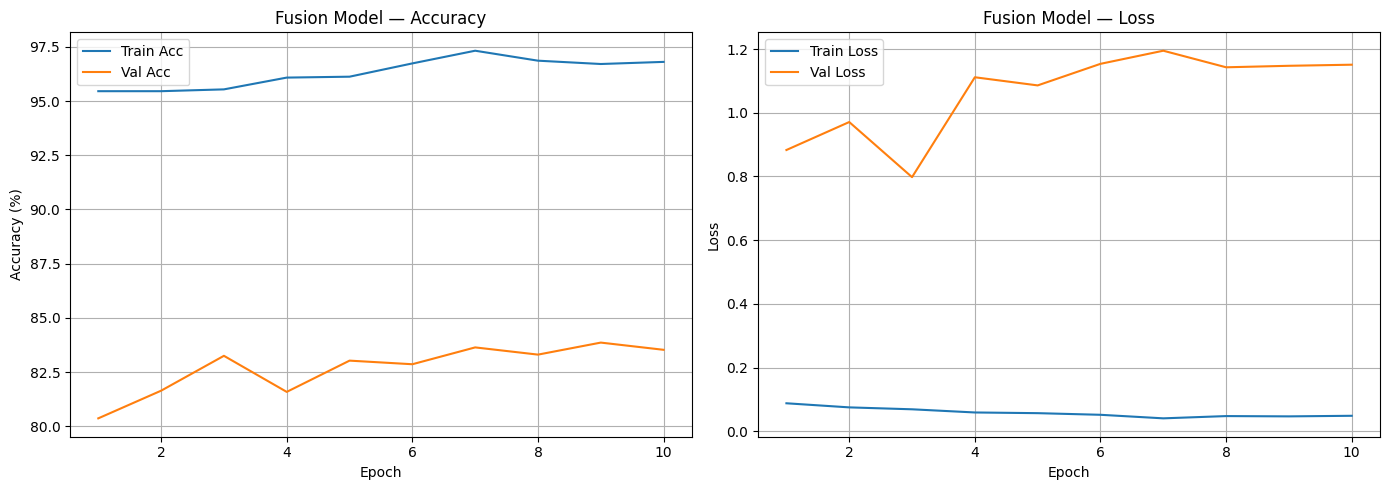

In [5]:
# ===== FUSION SNIPPET 4 — PLOTS =====

import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(14,5))

# ACCURACY
plt.subplot(1,2,1)
plt.plot(epochs, [x*100 for x in history["train_acc"]], label="Train Acc")
plt.plot(epochs, [x*100 for x in history["val_acc"]], label="Val Acc")
plt.title("Fusion Model — Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

# LOSS
plt.subplot(1,2,2)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.title("Fusion Model — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


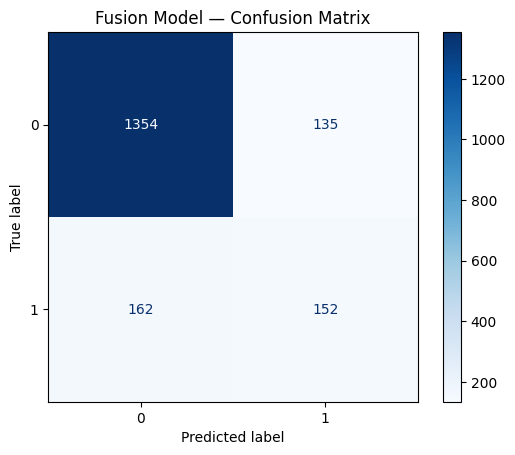

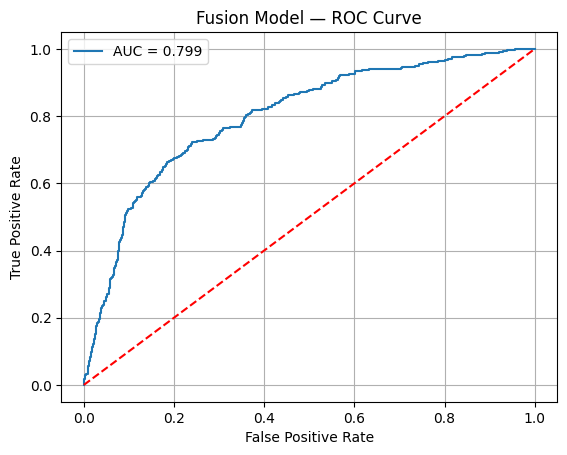


==== Fusion Classification Report ====

              precision    recall  f1-score   support

      AU (0)       0.89      0.91      0.90      1489
      TP (1)       0.53      0.48      0.51       314

    accuracy                           0.84      1803
   macro avg       0.71      0.70      0.70      1803
weighted avg       0.83      0.84      0.83      1803



In [6]:
# ===== FUSION SNIPPET 5 — TEST EVAL =====

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, roc_curve, auc

fusion_model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        out = fusion_model(imgs)
        probs = torch.softmax(out, dim=1)

        preds = probs.argmax(1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs[:,1].cpu().numpy())

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Fusion Model — Confusion Matrix")
plt.show()

# ROC CURVE
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("Fusion Model — ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# FULL REPORT
print("\n==== Fusion Classification Report ====\n")
print(classification_report(y_true, y_pred, target_names=["AU (0)", "TP (1)"]))


In [9]:
history_eff = {
    "train_loss": [
        0.6862,
        0.2855,
        0.1916,
        0.1470,
        0.1147,
        0.0813,
        0.0694,
        0.0619,
        0.0574,
        0.0495
    ],
    "train_acc": [
        0.6805,
        0.8315,
        0.8846,
        0.9138,
        0.9312,
        0.9497,
        0.9593,
        0.9634,
        0.9660,
        0.9699
    ],
    "val_loss": [
        1.4039,
        1.0306,
        0.9975,
        0.8959,
        0.8410,
        0.8423,
        0.8617,
        0.8368,
        0.8304,
        0.8305
    ],
    "val_acc": [
        0.5990,
        0.7105,
        0.7249,
        0.7687,
        0.7892,
        0.7987,
        0.8026,
        0.8098,
        0.8159,
        0.8159
    ]
}


In [10]:
history_vit = {
    "train_loss": [
        0.5448,
        0.4526,
        0.4442,
        0.4141,
        0.3549,
        0.2820,
        0.2247,
        0.1662,
        0.1142,
        0.0877
    ],
    "train_acc": [
        0.5116,
        0.5119,
        0.5144,
        0.5650,
        0.6519,
        0.7523,
        0.8210,
        0.8853,
        0.9275,
        0.9455
    ],
    "val_loss": [
        1.2478,
        1.1935,
        0.8913,
        1.2781,
        1.2746,
        0.7776,
        0.6874,
        0.8816,
        0.7204,
        0.7437
    ],
    "val_acc": [
        0.1742,
        0.1791,
        0.4409,
        0.3600,
        0.3716,
        0.6733,
        0.7460,
        0.6761,
        0.7743,
        0.8020
    ]
}


In [11]:
history_fusion = {
    "train_loss": [
        0.0880,
        0.0751,
        0.0690,
        0.0591,
        0.0569,
        0.0518,
        0.0407,
        0.0478,
        0.0469,
        0.0487
    ],
    "train_acc": [
        0.9546,
        0.9546,
        0.9554,
        0.9608,
        0.9613,
        0.9674,
        0.9732,
        0.9686,
        0.9671,
        0.9681
    ],
    "val_loss": [
        0.8830,
        0.9707,
        0.7978,
        1.1113,
        1.0857,
        1.1534,
        1.1946,
        1.1426,
        1.1473,
        1.1507
    ],
    "val_acc": [
        0.8037,
        0.8164,
        0.8325,
        0.8159,
        0.8303,
        0.8286,
        0.8364,
        0.8331,
        0.8386,
        0.8353
    ]
}


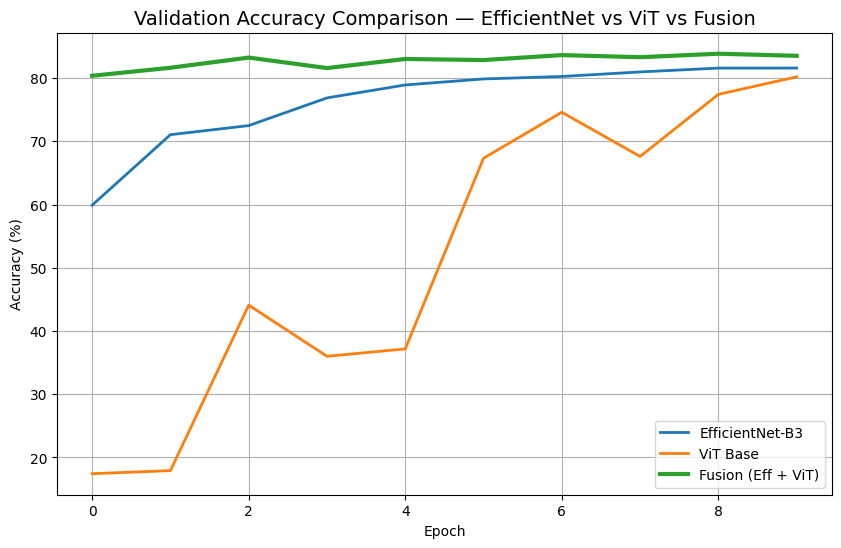

In [12]:
# ======== COMBINED VALIDATION ACCURACY CURVE ========

import matplotlib.pyplot as plt

epochs = range(1, 11)

plt.figure(figsize=(10,6))
plt.plot([x*100 for x in history_eff["val_acc"]], label="EfficientNet-B3", linewidth=2)
plt.plot([x*100 for x in history_vit["val_acc"]], label="ViT Base", linewidth=2)
plt.plot([x*100 for x in history_fusion["val_acc"]], label="Fusion (Eff + ViT)", linewidth=3)

plt.title("Validation Accuracy Comparison — EfficientNet vs ViT vs Fusion", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.legend()
plt.show()


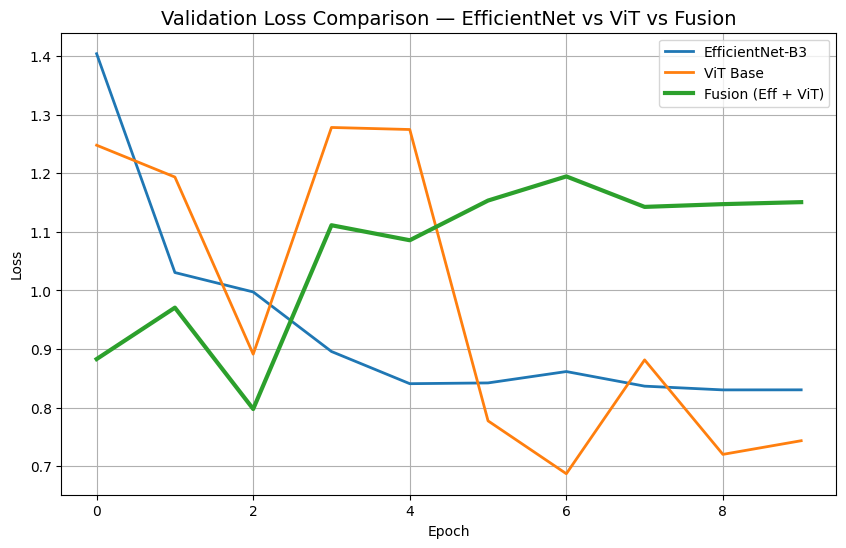

In [13]:
# ======== COMBINED VALIDATION LOSS CURVE ========

plt.figure(figsize=(10,6))
plt.plot(history_eff["val_loss"], label="EfficientNet-B3", linewidth=2)
plt.plot(history_vit["val_loss"], label="ViT Base", linewidth=2)
plt.plot(history_fusion["val_loss"], label="Fusion (Eff + ViT)", linewidth=3)

plt.title("Validation Loss Comparison — EfficientNet vs ViT vs Fusion", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name tf_efficientnet_b3_ns to current tf_efficientnet_b3.ns_jft_in1k.
  model = create_fn(


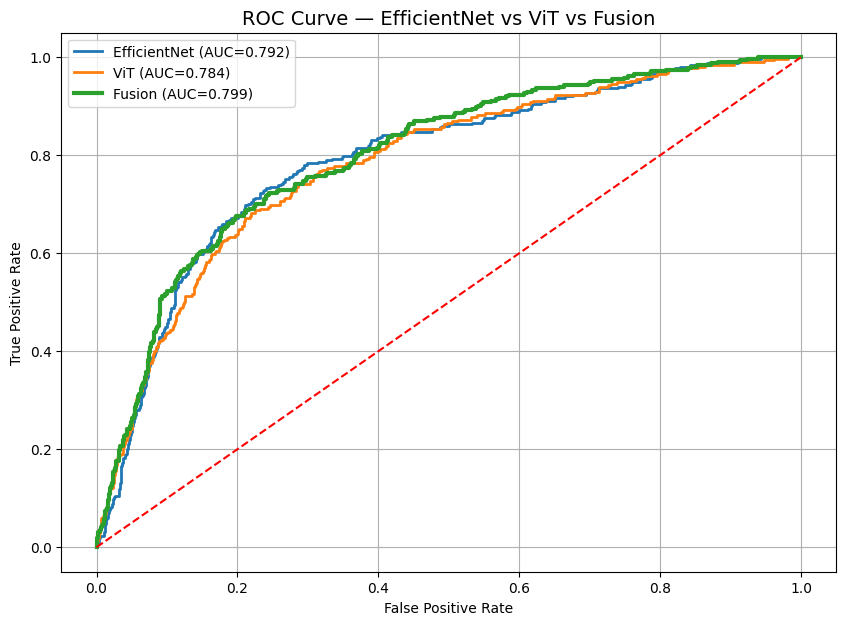

In [14]:
# ======== COMBINED ROC: EfficientNet vs ViT vs Fusion =========
from sklearn.metrics import roc_curve, auc
import torch
import numpy as np

def get_probs(model, loader):
    model.eval()
    y_true = []
    y_prob = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            out = model(imgs)
            prob = torch.softmax(out, dim=1)[:,1]
            y_true.extend(labels.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())
    return np.array(y_true), np.array(y_prob)

# Load EfficientNet
eff_model = timm.create_model("tf_efficientnet_b3_ns", pretrained=False, num_classes=2).to(device)
eff_model.load_state_dict(torch.load("/content/drive/MyDrive/morph_project/models/efficientnet_b3_retrained.pth"))
y_eff_true, y_eff_prob = get_probs(eff_model, val_loader)

# Load ViT
vit_model = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=2).to(device)
vit_model.load_state_dict(torch.load("/content/drive/MyDrive/morph_project/models/vit_retrained.pth"))
y_vit_true, y_vit_prob = get_probs(vit_model, val_loader)

# Load Fusion
fusion_model.load_state_dict(torch.load("/content/drive/MyDrive/morph_project/models/fusion_retrained.pth"))
y_fus_true, y_fus_prob = get_probs(fusion_model, val_loader)

# ROC calculations
f_eff, t_eff, _ = roc_curve(y_eff_true, y_eff_prob)
f_vit, t_vit, _ = roc_curve(y_vit_true, y_vit_prob)
f_fus, t_fus, _ = roc_curve(y_fus_true, y_fus_prob)

auc_eff = auc(f_eff, t_eff)
auc_vit = auc(f_vit, t_vit)
auc_fus = auc(f_fus, t_fus)

# Plot ROC
plt.figure(figsize=(10,7))
plt.plot(f_eff, t_eff, label=f"EfficientNet (AUC={auc_eff:.3f})", linewidth=2)
plt.plot(f_vit, t_vit, label=f"ViT (AUC={auc_vit:.3f})", linewidth=2)
plt.plot(f_fus, t_fus, label=f"Fusion (AUC={auc_fus:.3f})", linewidth=3)
plt.plot([0,1], [0,1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — EfficientNet vs ViT vs Fusion", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


In [15]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Device: cuda
✅ Fusion model loaded & ready!

📤 Upload images to test...


Saving img0.1.png to img0.1.png

===== Processing: img0.1.png =====


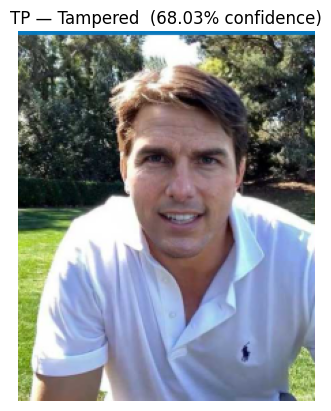


🔍 Prediction: TP — Tampered
🎯 Confidence: 68.03%
🖼 File: img0.1.png


In [18]:
# ==========================
# 🔥 FINAL FUSION INFERENCE
# ==========================

import torch, timm, cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# =====================
# 1. LOAD FUSION MODEL
# =====================

class EfficientNetBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        # NOTE: we purposely use 'model' because your saved weights use 'eff.model.xxx'
        self.model = timm.create_model(
            "tf_efficientnet_b3_ns",
            pretrained=False,
            num_classes=2
        )
        in_features = self.model.classifier.in_features
        self.model.classifier = nn.Identity()
        self.out_dim = in_features

    def forward(self, x):
        return self.model(x)



class ViTBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        # NOTE: use 'model' because saved weights use 'vit.model.xxx'
        self.model = timm.create_model(
            "vit_base_patch16_224",
            pretrained=False,
            num_classes=2
        )
        in_features = self.model.head.in_features
        self.model.head = nn.Identity()
        self.out_dim = in_features

    def forward(self, x):
        return self.model(x)



class FusionModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.eff = EfficientNetBackbone()
        self.vit = ViTBackbone()

        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(1536 + 768, 1024),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(1024, 256),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(256, 2)
        )

    def forward(self, x):
        eff_emb = self.eff(x)
        vit_emb = self.vit(x)
        fused = torch.cat([eff_emb, vit_emb], dim=1)
        return self.classifier(fused)

# load fusion weights
fusion_model = FusionModel().to(device)
fusion_model.load_state_dict(
    torch.load("/content/drive/MyDrive/morph_project/models/fusion_retrained.pth", map_location=device),
    strict=False
)

fusion_model.eval()

print("✅ Fusion model loaded & ready!")


# =============================
# 2. PREPROCESSING FOR INFERENCE
# =============================

def preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # normalize using standardized training normalization
    img = img.astype(np.float32)
    img = (img - img.mean()) / (img.std() + 1e-7)

    img = torch.tensor(img).permute(2,0,1).unsqueeze(0).to(device)
    return img


# =============================
# 3. PREDICT FUNCTION
# =============================

def predict(path):
    img_tensor = preprocess_image(path)

    with torch.no_grad():
        out = fusion_model(img_tensor)
        probs = torch.softmax(out, dim=1)[0].cpu().numpy()

    pred = np.argmax(probs)
    conf = float(max(probs) * 100)

    label = "AU — Authentic" if pred == 0 else "TP — Tampered"

    # display image
    img_show = cv2.imread(path)
    img_show = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
    plt.imshow(img_show)
    plt.axis("off")
    plt.title(f"{label}  ({conf:.2f}% confidence)")
    plt.show()

    print("\n🔍 Prediction:", label)
    print("🎯 Confidence:", f"{conf:.2f}%")
    print("🖼 File:", path)


# =============================
# 4. UPLOAD + RUN PREDICTIONS
# =============================

print("\n📤 Upload images to test...")
uploaded = files.upload()

for name in uploaded.keys():
    print(f"\n===== Processing: {name} =====")
    predict(name)
